In [20]:
import os
import torch
import timm
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System Check: Using {device.type.upper()}")

System Check: Using CUDA


In [22]:
root_dir = "BreaKHis_v1"
data = []
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.png'):
            file_path = os.path.join(root, file)

            parts = os.path.normpath(file_path).split(os.sep)

            label_str = parts[-6]
            tumor_type = parts[-4]
            patient_id = parts[-3]
            magnification = parts[-2]

            label = 0 if label_str == 'benign' else 1

            data.append({
                'image_path': file_path,
                'patient_id': patient_id,
                'tumor_type': tumor_type,
                'magnification': magnification,
                'label': label
            })
df = pd.DataFrame(data)

total_benign = df[df['label'] == 0].shape[0]
total_malignant = df[df['label'] == 1].shape[0]
print(f"Total Benign: {total_benign} | Total Malignant: {total_malignant}")

Total Benign: 2480 | Total Malignant: 5429


In [23]:
class BreaKHisDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [24]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df['patient_id']))

val_df = df.iloc[val_idx].reset_index(drop=True)

print(f"Validation: {len(val_df)} images ({val_df['patient_id'].nunique()} patients)")

val_dataset = BreaKHisDataset(val_df, transform=val_transform)

batches = 32

val_loader = DataLoader(
        val_dataset,
        batch_size=batches,
        shuffle=False,
        pin_memory=True
    )

Validation: 1637 images (17 patients)


In [25]:
#----------------------------------------------#
#---Change cell as needed depending on model---#
#----------------------------------------------#
#--------------Model & Classifier--------------#
model_name = 'resnet'
if model_name == 'densenet':
    model = models.densenet169(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
)
elif model_name == 'resnet':
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
)
elif model_name == 'inception':
    model = timm.create_model('inception_resnet_v2', pretrained=False)
    in_features = model.classif.in_features
    model.classif = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
    )
#----------------------------------------------#
#------------------Model Path------------------#
folder = 'ResNetModels/'
model_prefix = 'Resnet_0_'
model_name = 'ClaL4_v0_auc_auc'

path = folder+model_prefix+model_name+".pth"
#----------------------------------------------#

model.load_state_dict(torch.load(path , map_location=device, weights_only=True))
model = model.to(device)
print(f"Trained weights successfully loaded for {path}")

Trained weights successfully loaded for ResNetModels/Resnet_0_ClaL4_v0_auc_auc.pth


--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.10 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.8421     | Acc: 0.7434
Score    | Recall: 1.0000  | Spec: 0.1876     | Total Images: 1637
Detected | TP:      1120   | TN:   97         | Total Clears: 1217
Errors   | FN:      0      | FP:   420        | Total Errors: 420
----------------------------------------------------------------------


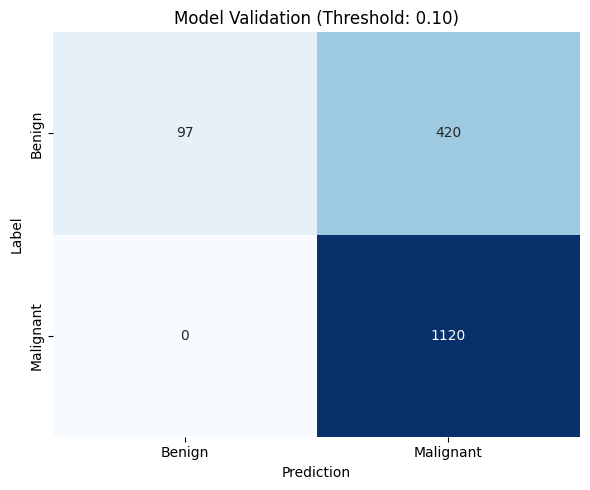

--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.15 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.8740     | Acc: 0.8027
Score    | Recall: 1.0000  | Spec: 0.3752     | Total Images: 1637
Detected | TP:      1120   | TN:   194        | Total Clears: 1314
Errors   | FN:      0      | FP:   323        | Total Errors: 323
----------------------------------------------------------------------


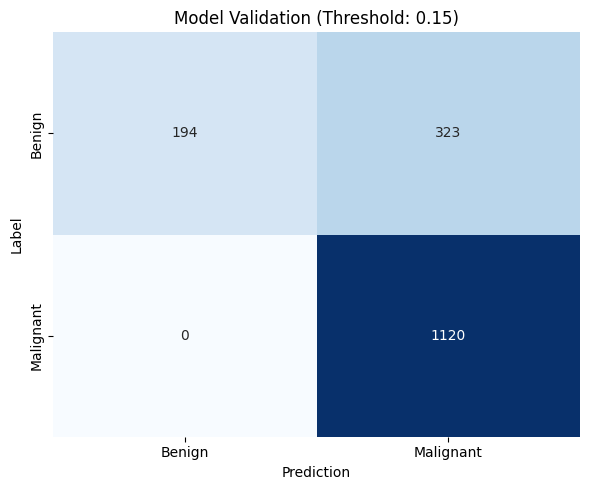

--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.20 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.8927     | Acc: 0.8363
Score    | Recall: 0.9955  | Spec: 0.4913     | Total Images: 1637
Detected | TP:      1115   | TN:   254        | Total Clears: 1369
Errors   | FN:      5      | FP:   263        | Total Errors: 268
----------------------------------------------------------------------


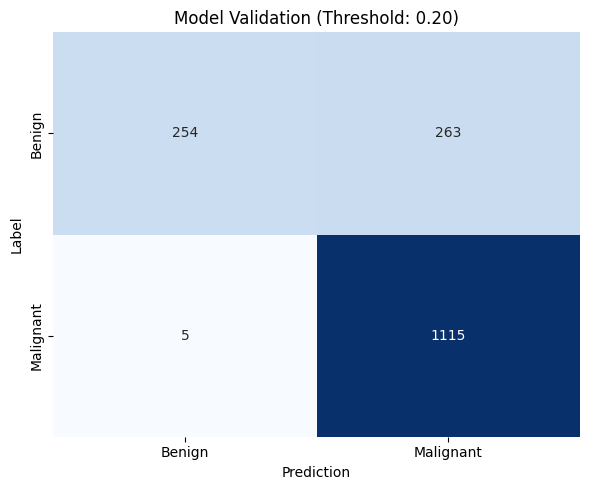

--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.25 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.9115     | Acc: 0.8681
Score    | Recall: 0.9929  | Spec: 0.5977     | Total Images: 1637
Detected | TP:      1112   | TN:   309        | Total Clears: 1421
Errors   | FN:      8      | FP:   208        | Total Errors: 216
----------------------------------------------------------------------


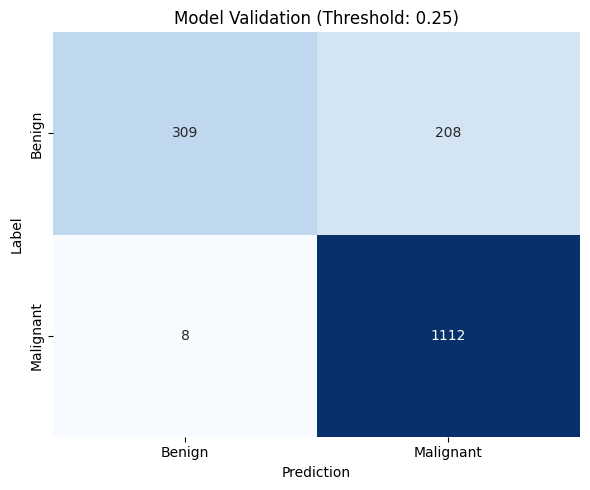

--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.30 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.9245     | Acc: 0.8900
Score    | Recall: 0.9839  | Spec: 0.6867     | Total Images: 1637
Detected | TP:      1102   | TN:   355        | Total Clears: 1457
Errors   | FN:      18     | FP:   162        | Total Errors: 180
----------------------------------------------------------------------


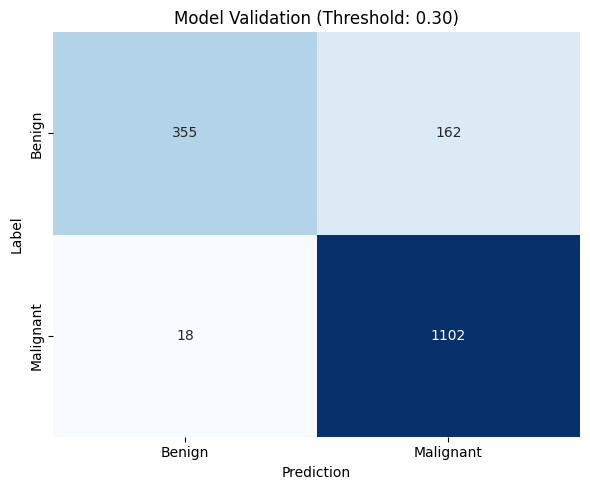

--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.35 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.9251     | Acc: 0.8937
Score    | Recall: 0.9589  | Spec: 0.7524     | Total Images: 1637
Detected | TP:      1074   | TN:   389        | Total Clears: 1463
Errors   | FN:      46     | FP:   128        | Total Errors: 174
----------------------------------------------------------------------


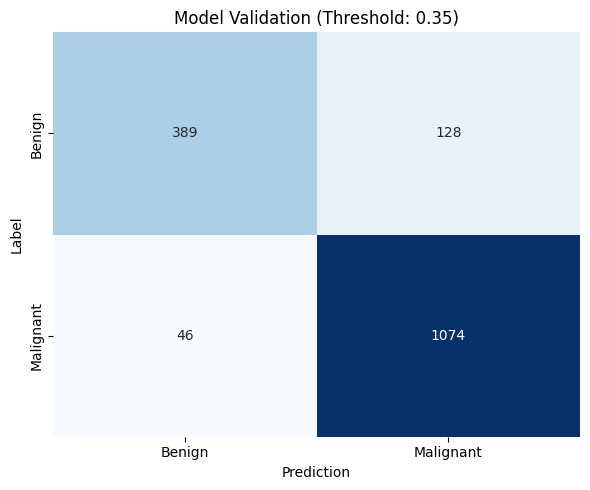

--- Dashboard for ClaL4_v0_auc_auc ---
Info     | Epoch:   N/A    | Threshold:  0.40 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9334  | F-1:  0.9206     | Acc: 0.8894
Score    | Recall: 0.9366  | Spec: 0.7872     | Total Images: 1637
Detected | TP:      1049   | TN:   407        | Total Clears: 1456
Errors   | FN:      71     | FP:   110        | Total Errors: 181
----------------------------------------------------------------------


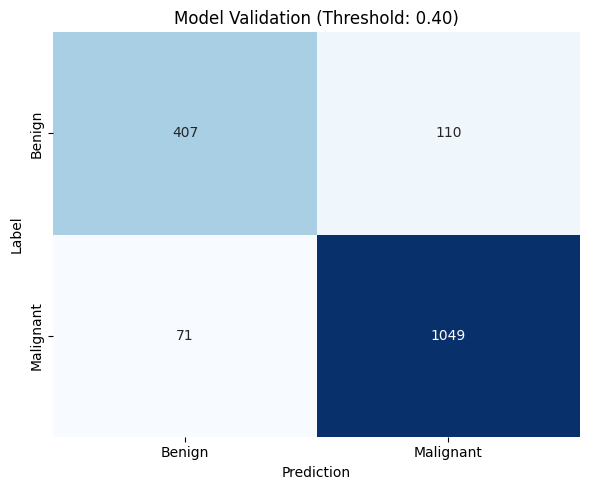

In [26]:
TTA_flag = True
thresh_start=0.10
thresh_end=0.40
step=0.05

model.eval()
all_labels = []
all_probs  = []

for inputs, labels in tqdm(val_loader, desc="Evaluating", leave=False):
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        if TTA_flag:
            img_hflip  = torch.flip(inputs, dims=[3])
            img_vflip  = torch.flip(inputs, dims=[2])
            img_rot90  = torch.rot90(inputs, k=1, dims=[2, 3])

            prob_orig  = torch.sigmoid(outputs)
            prob_hflip = torch.sigmoid(model(img_hflip))
            prob_vflip = torch.sigmoid(model(img_vflip))
            prob_rot90 = torch.sigmoid(model(img_rot90))

            probs = (prob_orig + prob_hflip + prob_vflip + prob_rot90) / 4.0
        else:
            probs = torch.sigmoid(outputs)

    all_labels.extend(labels.cpu().numpy())
    all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

auc = roc_auc_score(all_labels, all_probs)

thresholds = np.arange(thresh_start, thresh_end + (step / 2), step)

for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    cm = confusion_matrix(all_labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    TC = tn + tp
    TE = fn + fp
    TI = TC + TE
    specificity = tn / (tn + fp)

    print(f"--- Dashboard for {model_name} ---")
    print(f"Info     | Epoch:   N/A    | Threshold:  {thresh:.2f} | LR: N/A")
    print(f"Loss     | Train:   N/A    | Validation: N/A  |")
    print(f"Metrics  | AUCROC: {auc:.4f}  | F-1:  {f1:.4f}     | Acc: {acc:.4f}")
    print(f"Score    | Recall: {recall:.4f}  | Spec: {specificity:.4f}     | Total Images: {TI}")
    print(f"Detected | TP:      {tp:<4}   | TN:   {tn:<3}        | Total Clears: {TC}")
    print(f"Errors   | FN:      {fn:<4}   | FP:   {fp:<3}        | Total Errors: {TE}")
    print("-" * 70)

    #Plot the Visual Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Model Validation (Threshold: {thresh:.2f})")
    plt.ylabel('Label')
    plt.xlabel('Prediction')
    plt.tight_layout()
    plt.show()